# PhoSenti — Vietnamese Sentiment Analysis
Fine-tuning PhoBERT on the UIT-VSFC student feedback corpus.

**Phases covered in this notebook:**
1. Data & Exploration
2. Fine-tuning
3. Inference & API prep

## 0. Install dependencies

In [1]:
!pip install transformers datasets torch scikit-learn fastapi uvicorn


## Phase 1 — Data & Exploration

In [2]:
from datasets import load_dataset

dataset = load_dataset("ura-hcmut/UIT-VSFC")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 11426
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1584
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3166
    })
})


In [3]:
# Inspect a few examples
for example in dataset["train"].select(range(5)):
    print(example)

{'text': 'slide giáo trình đầy đủ .', 'label': 'positive'}
{'text': 'nhiệt tình giảng dạy , gần gũi với sinh viên .', 'label': 'positive'}
{'text': 'đi học đầy đủ full điểm chuyên cần .', 'label': 'negative'}
{'text': 'chưa áp dụng công nghệ thông tin và các thiết bị hỗ trợ cho việc giảng dạy .', 'label': 'negative'}
{'text': 'thầy giảng bài hay , có nhiều bài tập ví dụ ngay trên lớp .', 'label': 'positive'}


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Label distribution
# UIT-VSFC sentiment labels: 0 = negative, 1 = neutral, 2 = positive
label_names = ["negative", "neutral", "positive"]

for split in ["train", "validation", "test"]:
    df = pd.DataFrame(dataset[split])
    counts = df["label"].value_counts().sort_index()
    print(f"\n{split} split ({len(df)} examples):")
    for label, count in counts.items():
        print(f"  {label}: {count} examples")


train split (11426 examples):
  negative: 5325 examples
  neutral: 458 examples
  positive: 5643 examples

validation split (1584 examples):
  negative: 705 examples
  neutral: 73 examples
  positive: 805 examples

test split (3166 examples):
  negative: 1409 examples
  neutral: 167 examples
  positive: 1590 examples


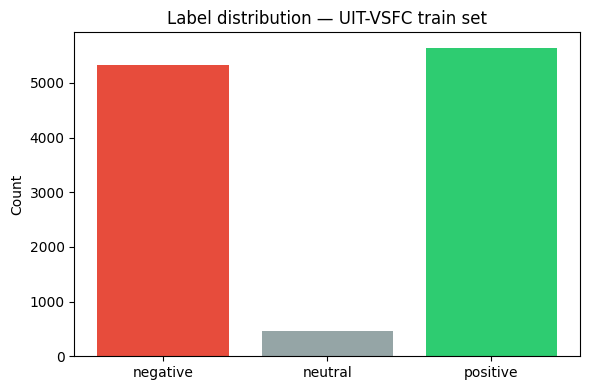

In [5]:
# Plot label distribution for the training set
train_df = pd.DataFrame(dataset["train"])
counts = train_df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(label_names, counts.values, color=["#e74c3c", "#95a5a6", "#2ecc71"])
plt.title("Label distribution — UIT-VSFC train set")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Phase 1 — Tokenizer Check

In [6]:
from transformers import AutoTokenizer

MODEL_NAME = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_text = "Thầy giảng rất dễ hiểu và nhiệt tình hỗ trợ sinh viên."
tokens = tokenizer(sample_text, return_tensors="pt", truncation=True, max_length=256)

print("Input IDs:", tokens["input_ids"])
print("Attention mask:", tokens["attention_mask"])
print("Decoded:", tokenizer.decode(tokens["input_ids"][0]))

Input IDs: tensor([[    0,  5005,  5415,    59,   592,   563,     6,  2515,   939, 43451,
         18075,   418, 34946, 10557,     2]])
Attention mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
Decoded: <s> Thầy giảng rất dễ hiểu và nhiệt tình hỗ trợ sinh viên. </s>


## Phase 1 — Dataset Tokenization

In [7]:
MAX_LENGTH = 256

label2id = {"negative": 0, "neutral": 1, "positive": 2}

def tokenize(batch):
    encoding = tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )
    encoding["labels"] = [label2id[l] for l in batch["label"]]
    return encoding

dataset_clean = dataset.filter(lambda x: x["text"] is not None)

tokenized = dataset_clean.map(tokenize, batched=True, remove_columns=["text", "label"])

print(tokenized)
print("Features:", tokenized["train"].features)

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 11426
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1583
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3166
    })
})
Features: {'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None), 'labels': Value(dtype='int64', id=None)}


## Phase 2 — Model

In [8]:
from transformers import AutoModelForSequenceClassification

NUM_LABELS = 3

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)
print(model.config)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initia

RobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "RobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 258,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "tie_word_embeddings": true,
  "tokenizer_class": "PhobertTokenizer",
  "transformers_version": "5.5.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 64001
}



## Phase 2 — Training

In [9]:
from transformers import TrainingArguments, Trainer, DefaultDataCollator
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro"),
    }

training_args = TrainingArguments(
    output_dir="checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    fp16=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    compute_metrics=compute_metrics,
    data_collator=DefaultDataCollator(),
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.220508,0.242595,0.938092,0.816494
2,0.208517,0.235173,0.944409,0.838591
3,0.131278,0.251448,0.945673,0.840183


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2145, training_loss=0.21541902257568074, metrics={'train_runtime': 2194.6539, 'train_samples_per_second': 15.619, 'train_steps_per_second': 0.977, 'total_flos': 4509500866440192.0, 'train_loss': 0.21541902257568074, 'epoch': 3.0})

In [15]:
import torch
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, DefaultDataCollator
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

best_model = AutoModelForSequenceClassification.from_pretrained("checkpoints/best")
best_model.eval()

loader = DataLoader(tokenized["test"], batch_size=32, collate_fn=DefaultDataCollator())

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in loader:
        logits = best_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits
        preds = torch.argmax(logits, dim=-1).numpy()
        labels = batch["labels"].numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

print("Accuracy:", round(accuracy_score(all_labels, all_preds), 4))
print("F1 macro:", round(f1_score(all_labels, all_preds, average="macro"), 4))
print("F1 per class:", f1_score(all_labels, all_preds, average=None).round(4))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Accuracy: 0.9334
F1 macro: 0.8246
F1 per class: [0.9494 0.5745 0.9499]


## Phase 3 — Inference

In [18]:
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
label_names = ["negative", "neutral", "positive"]

model.to(device)
model.eval()

def predict(text: str) -> dict:
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = F.softmax(logits, dim=-1).squeeze().tolist()
    predicted_idx = int(torch.argmax(logits))
    return {
        "text": text,
        "sentiment": label_names[predicted_idx],
        "confidence": round(probs[predicted_idx], 4),
        "scores": {
            label_names[i]: round(probs[i], 4) for i in range(3)
        },
    }

print(predict("Thầy giảng rất dễ hiểu và nhiệt tình hỗ trợ sinh viên."))
print(predict("Môn học này thực sự rất chán và khó hiểu."))
print(predict("Bài tập vừa đủ, không quá khó."))
print(predict("Thầy dạy bình thường, bài tập cũng vừa phải"))

{'text': 'Thầy giảng rất dễ hiểu và nhiệt tình hỗ trợ sinh viên.', 'sentiment': 'positive', 'confidence': 0.9975, 'scores': {'negative': 0.0014, 'neutral': 0.001, 'positive': 0.9975}}
{'text': 'Môn học này thực sự rất chán và khó hiểu.', 'sentiment': 'negative', 'confidence': 0.9923, 'scores': {'negative': 0.9923, 'neutral': 0.0011, 'positive': 0.0065}}
{'text': 'Bài tập vừa đủ, không quá khó.', 'sentiment': 'positive', 'confidence': 0.9951, 'scores': {'negative': 0.002, 'neutral': 0.0029, 'positive': 0.9951}}
{'text': 'Thầy dạy bình thường, bài tập cũng vừa phải', 'sentiment': 'positive', 'confidence': 0.9973, 'scores': {'negative': 0.0013, 'neutral': 0.0014, 'positive': 0.9973}}


## Phase 3 — Save model for API

In [19]:
# Save the best model and tokenizer so app.py can load them
model.save_pretrained("checkpoints/best")
tokenizer.save_pretrained("checkpoints/best")
print("Model saved to checkpoints/best/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to checkpoints/best/
